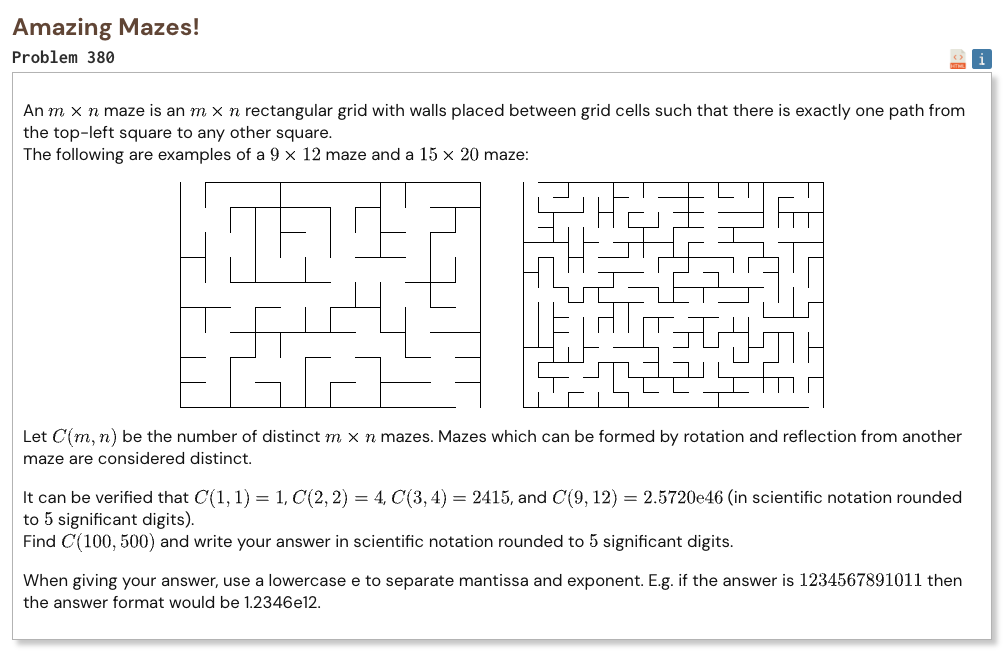

## Initial approach

* treat every grid cell as a vertex and every possible opening as an edge
* a valid maze must connect all cells without creating any cycle
* this means each maze is exactly a spanning tree of the rectangular grid graph
* use the matrix tree theorem to count the spanning trees
* the grid Laplacian eigenvalues can be written using cosine values
* multiply every nonzero eigenvalue and divide by the number of cells
* use logarithms because the final number is far too large to store directly
* recover the mantissa and exponent from the total base ten logarithm

In [1]:
from math import cos, floor, log10, pi


def solve(rows, columns):
    total_log = -log10(rows * columns)

    row_cosines = [cos(pi * i / rows) for i in range(rows)]
    column_cosines = [cos(pi * j / columns) for j in range(columns)]

    for i in range(rows):
        for j in range(columns):
            if i == 0 and j == 0:
                continue

            eigenvalue = (
                4
                - 2 * row_cosines[i]
                - 2 * column_cosines[j]
            )

            total_log += log10(eigenvalue)

    exponent = floor(total_log)
    mantissa = 10 ** (total_log - exponent)
    mantissa = round(mantissa, 4)

    if mantissa >= 10:
        mantissa /= 10
        exponent += 1

    return f"{mantissa:.4f}e{exponent}"


assert solve(1, 1) == "1.0000e0"
assert solve(2, 2) == "4.0000e0"
assert solve(3, 4) == "2.4150e3"
assert solve(9, 12) == "2.5720e46"

In [2]:
%%time
result = solve(100, 500)
print("Result:", result)

Result: 6.3202e25093
CPU times: user 9.57 ms, sys: 379 μs, total: 9.95 ms
Wall time: 9.89 ms
